This shows what the CNN filters look like.
  Filters detect pattern

It helps Python interact with your system files and folders.(os module)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile
import os

zip_path = "dataset.zip"  # your file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")


os.listdir("dataset")

['yes', 'brain_tumor_dataset', 'no']

In [ ]:
import shutil

shutil.rmtree("dataset/brain_tumor_dataset")

import os
print(os.listdir("dataset"))

['yes', 'no']


In [ ]:
print("Tumor:", len(os.listdir("dataset/yes")))
print("No Tumor:", len(os.listdir("dataset/no")))

Tumor: 155
No Tumor: 98


In [ ]:
img_size = 128
batch_size = 32

train_data = keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_data = keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    # Default pool size = 2×2
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),


    layers.Dense(1, activation='sigmoid')   # Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=11
)

Epoch 1/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5419 - loss: 0.9768 - val_accuracy: 0.6400 - val_loss: 0.6877
Epoch 2/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 954ms/step - accuracy: 0.6108 - loss: 0.6660 - val_accuracy: 0.6400 - val_loss: 0.6554
Epoch 3/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6059 - loss: 0.6547 - val_accuracy: 0.6600 - val_loss: 0.6491
Epoch 4/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 955ms/step - accuracy: 0.6502 - loss: 0.6128 - val_accuracy: 0.7800 - val_loss: 0.5876
Epoch 5/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7438 - loss: 0.5488 - val_accuracy: 0.7800 - val_loss: 0.5523
Epoch 6/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7389 - loss: 0.5217 - val_accuracy: 0.8000 - val_loss: 0.5298
Epoch 7/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 971ms/step - accuracy: 0.7734 - loss: 0.4868 - val_accuracy: 0.8000 - val_loss: 0.5374
Epoch 8/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 958ms/step - accuracy: 0.7586 - loss: 0.4999 - val_accuracy: 0.8000 - val_loss: 0.5348
Ep

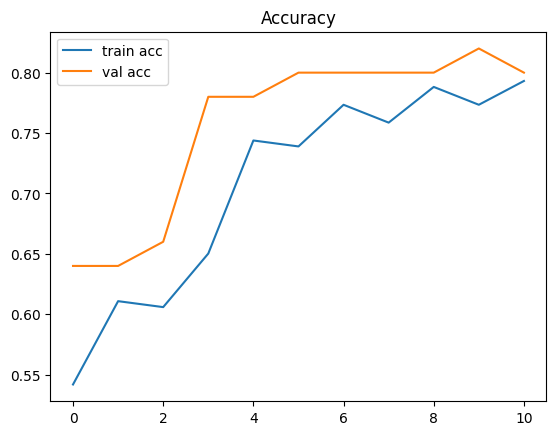

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


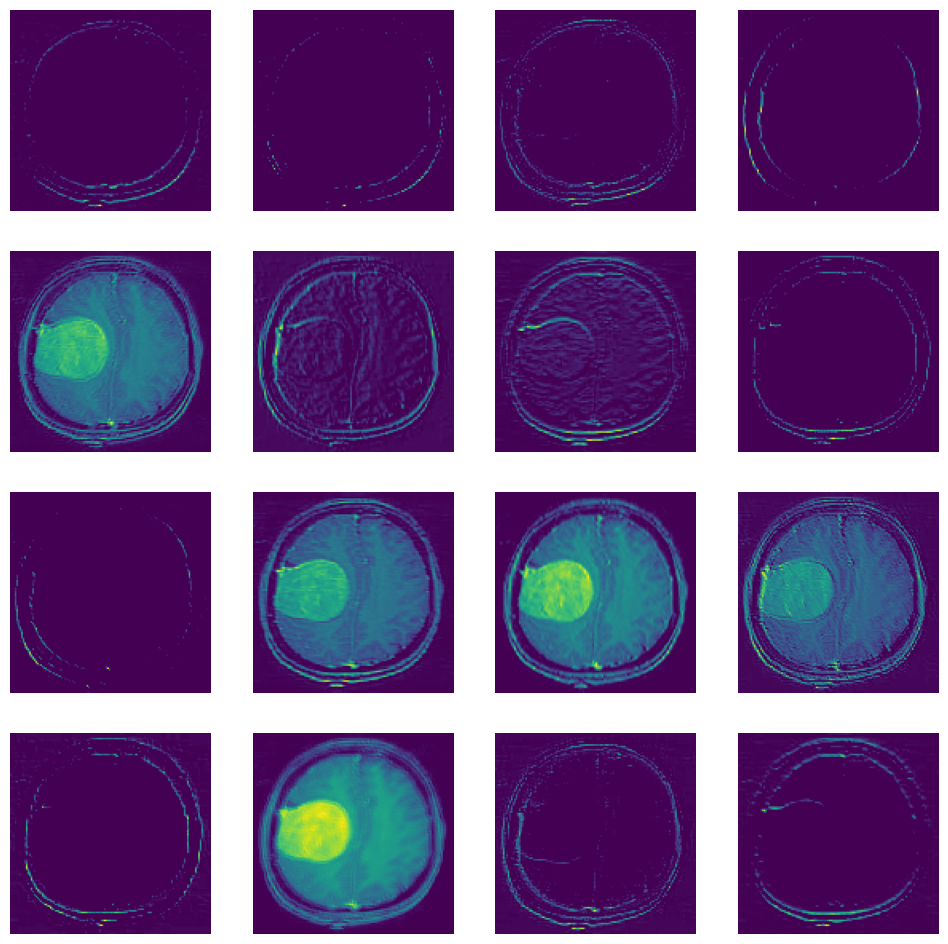

In [ ]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

# ✅ FIXED LINE
activation_model = keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

# Load image
img_path = "dataset/yes/Y1.jpg"
img = keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

activations = activation_model.predict(img_array)

# Plot filters
layer_activation = activations[0]

plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(layer_activation[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Using layer: conv2d_2


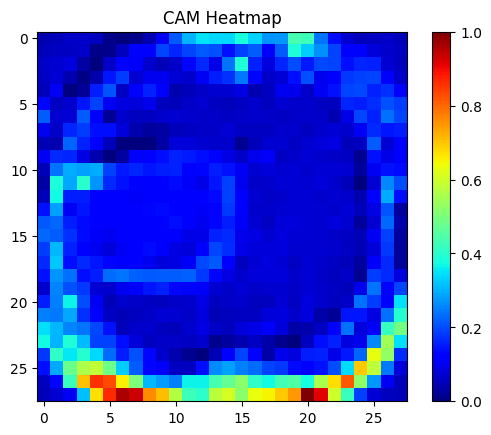

In [ ]:
# 🔥 Step 1: Build model
_ = model.predict(np.zeros((1,128,128,3)))

# 🔥 Step 2: Get last conv layer
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Using layer:", last_conv_layer.name)

# 🔥 Step 3: Grad model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.outputs[0]]
)

# 🔥 Step 4: Gradient
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

# 🔥 Step 5: Heatmap
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

# ❌ NO .numpy() HERE

# 🔥 Step 6: Show
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("CAM Heatmap")
plt.show()

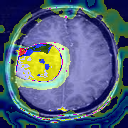

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

cv2_imshow(superimposed_img.astype('uint8'))